In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


# Adat betöltése

Töltsd be a boston.csv-t egy data frame-be és plotold ki az első 5 sort.

Forrás: Forrás:https://www.kaggle.com/code/prasadperera/the-boston-housing-dataset

In [2]:
data = pd.read_csv('boston.csv')

data.head()


,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,3,0.03237,0.0,2.18,0,NaN,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


# Hiányzó értékek keresése

Íratsd ki hogy bizonyos oszlopban mennyi hiányzó érték van.

In [3]:
missing_values = data.isnull().sum()

missing_values

Unnamed: 0     0
crim           0
zn             0
indus          0
chas           0
nox           50
rm             0
age           25
dis           25
rad            0
tax            0
ptratio        0
b              0
lstat          0
medv           0
dtype: int64

# Hiányzó adatok kezelése

Kezeld a hiányzó értékeket a következő módon:
- now: átlaggal töltsd fel a hiányzó értékeket
- age: mediánnal töltsd fel a hiányzó értékeket
- dis: töröld ezeket a sorokat

In [4]:
# Átlaggal való feltöltés
data['nox'].fillna(data['nox'].mean(), inplace=True)

# Mediánnal való feltöltés
data['age'].fillna(data['age'].median(), inplace=True)

# Eldobjuk a hiányzó érékeket
data.dropna(subset=['dis'], inplace=True)

# Van-e még hiányzó érték?
missing_values_after = data.isnull().sum()

missing_values_after

C:\Users\Barna\AppData\Local\Temp\ipykernel_38356\1651789175.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['nox'].fillna(data['nox'].mean(), inplace=True)
C:\Users\Barna\AppData\Local\Temp\ipykernel_38356\1651789175.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assign

Unnamed: 0     0
crim           0
zn             0
indus          0
chas           0
nox           47
rm             0
age           23
dis            0
rad            0
tax            0
ptratio        0
b              0
lstat          0
medv           0
dtype: int64

# Vizualizáció

Vizualizáld az adathalmazt:
1. Histogrammon ábrázold az medv-et (ház árát)
2. Egy scatter plot-on ábrázold az x-tengelyen rm és az y-tengelyen a medv-et
3. Készíts egy korelációs hőtérképet
4. Ábrázold egy scatter ploton a lstat és a medv-et.

Minden esetben állís be labeleket és title-eket ahol lehetséges!

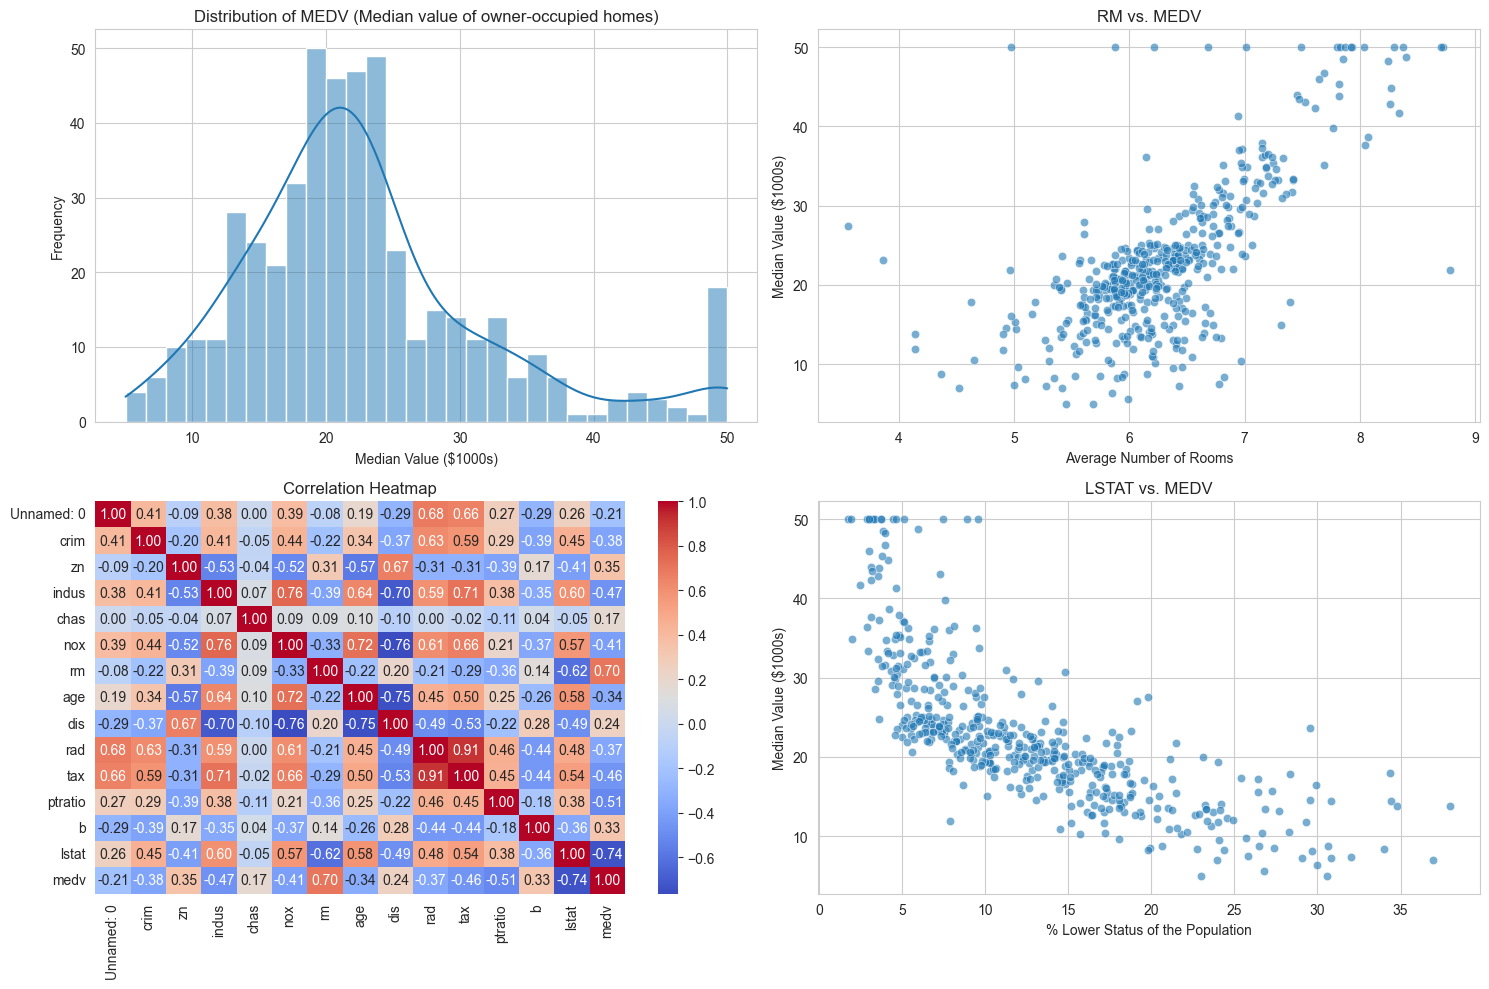

In [5]:

sns.set_style("whitegrid")

# subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: A saját tulajdonú lakások mediánértékének megoszlása (medv)
sns.histplot(data['medv'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of MEDV (Median value of owner-occupied homes)')
axes[0, 0].set_xlabel('Median Value ($1000s)')
axes[0, 0].set_ylabel('Frequency')

# Plot 2: Az RM (lakásonkénti szobák átlagos száma) és a MEDV szórásdiagramja
sns.scatterplot(x='rm', y='medv', data=data, ax=axes[0, 1], alpha=0.6)
axes[0, 1].set_title('RM vs. MEDV')
axes[0, 1].set_xlabel('Average Number of Rooms')
axes[0, 1].set_ylabel('Median Value ($1000s)')

# Plot 3: Correlation Heatmap
corr = data.corr()
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f", ax=axes[1, 0])
axes[1, 0].set_title('Correlation Heatmap')

# Plot 4: LSTAT (a lakosság alacsonyabb státuszú %-ának aránya) vs MEDV
sns.scatterplot(x='lstat', y='medv', data=data, ax=axes[1, 1], alpha=0.6)
axes[1, 1].set_title('LSTAT vs. MEDV')
axes[1, 1].set_xlabel('% Lower Status of the Population')
axes[1, 1].set_ylabel('Median Value ($1000s)')

plt.tight_layout()
plt.show()


# Előkészülés a tanításra

Válaszd ki a feature és target váltózó(kat) és split-eld szét az adathalmazd tanító és tesztelő adathalmazra. 80% legyen a tanító és 20% a teszt.

Mit és miért ezeket választottam ki?
- RM (szoba szám): Pozitív korrelációban áll a MEDV változóval; az ábrázolások azt sugallják, hogy a több szobával rendelkező otthonok magasabb mediánértéket érhetnek el.
- LSTAT (% alacsonyabb státuszú lakosság): Negatív korrelációban áll a MEDV változóval; azt mutatja, hogy a magasabb LSTAT értékű területeken az ingatlanok általában alacsonyabb mediánértéket érnek el.
- CRIM (bűnözési ráta): A terület bűnözési rátája negatívan befolyásolhatja az ingatlanok értékét.
- ZN (25,000 négyzetlábnál nagyobb területek aránya): Ez a változó azt mutatja, hogy egy adott terület milyen mértékben áll lakóhasználatra szánt nagy területekből; pozitív hatása lehet az ingatlanok árára.
- INDUS (nem kiskereskedelmi üzleti területek aránya): A nagyobb ipari területi arány negatívan befolyásolhatja az ingatlanok lakhatóságát és értékét.
- CHAS (Charles Folyóhoz való közeliség): Ez egy kategórikus változó, ami azt jelzi, hogy az ingatlan a Charles Folyó partján található-e. Pozitív hatással lehet az ingatlanok árára.
PTRATIO (tanuló-tanár arány): A magasabb tanuló-tanár arány negatívan befolyásolhatja az oktatás minőségének percepcióját, ezáltal az ingatlanok értékét is.

In [6]:

# Target & feature 
X = data[['rm', 'lstat', 'crim', 'zn', 'indus', 'chas', 'ptratio']]  # Predictor variables
Y = data['medv']  # Target variable

# spliting
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# check
(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)


((384, 7), (97, 7), (384,), (97,))

# Modell tanítása és értékelése

Tanítsd fel a modellt és értékeld ki!

In [7]:
linear_reg = LinearRegression()

# fit
linear_reg.fit(X_train, Y_train)

# pred on train
Y_train_pred = linear_reg.predict(X_train)

# pred on test
Y_test_pred = linear_reg.predict(X_test)

# metrics
train_mse = mean_squared_error(Y_train, Y_train_pred)
train_r2 = r2_score(Y_train, Y_train_pred)
test_mse = mean_squared_error(Y_test, Y_test_pred)
test_r2 = r2_score(Y_test, Y_test_pred)

(train_mse, train_r2, test_mse, test_r2)


(27.479558483051687, 0.6920403427231987, 25.89638625432737, 0.6454559845392187)

# Összegzés:

## MSE (Mean Squared Error)
- Tanító adathalmaz: Az MSE értéke 27.48 volt, ami azt jelzi, hogy a modell becslései és a tényleges értékek között átlagosan ennyi négyzetes eltérés van.
- Teszt adathalmaz: Az MSE értéke itt 25.90 volt, ami hasonlóan magas, és arra utal, hogy a modell becslései a teszt adathalmazon is hasonló hibaszintet mutatnak, mint a tanító adathalmazon.

## R^2(meghatározási együttható)
- Tanító adathalmaz: Az R^2 érték 0.69, ami azt jelzi, hogy a modell a változások 69%-át képes magyarázni a célváltozóban (ingatlanárak) a kiválasztott független változók segítségével. Van még mit javítani.
- Teszt adathalmaz: Az R^2 érték itt 0.65, ami közel áll a tanító adathalmaz R^2 értékéhez. Ez azt mutatja, hogy a modell általánosítási képessége elfogadható.

Ezek alapján ez egy sikeres POC. 